<a href="https://colab.research.google.com/github/OgunbanjoT/Lab2AI/blob/main/AI_Assignment5_Toyin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For visualizations
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Task 1: Load the Titanic dataset
url = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"
df = pd.read_csv(url)

print(f"Dataset loaded successfully! Shape: {df.shape}")

Dataset loaded successfully! Shape: (887, 8)


In [3]:
# Display the first 5 rows of the dataset
df.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [4]:
# Display the last 5 rows of the dataset
df.tail()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
882,0,2,Rev. Juozas Montvila,male,27.0,0,0,13.00
883,1,1,Miss. Margaret Edith Graham,female,19.0,0,0,30.00
884,0,3,Miss. Catherine Helen Johnston,female,7.0,1,2,23.45
885,1,1,Mr. Karl Howell Behr,male,26.0,0,0,30.00
886,0,3,Mr. Patrick Dooley,male,32.0,0,0,7.75


In [5]:
# Display the data types of each column
df.dtypes

,0
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
Siblings/Spouses Aboard,int64
Parents/Children Aboard,int64
Fare,float64


In [6]:
# Display summary statistics of the numerical columns
df.describe()

,Survived,Pclass,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
count,887.000000,887.000000,887.000000,887.000000,887.000000,887.00000
mean,0.385569,2.305524,29.471443,0.525366,0.383315,32.30542
std,0.487004,0.836662,14.121908,1.104669,0.807466,49.78204
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.00000
25%,0.000000,2.000000,20.250000,0.000000,0.000000,7.92500
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.45420
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.13750
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.32920


In [7]:
# Create a new categorical feature 'PclassCategory' from 'Pclass'
pclass_map = {1: '1st Class', 2: '2nd Class', 3: '3rd Class'}
df['PclassCategory'] = df['Pclass'].map(pclass_map)

# Create a 'CabinCategory' safely if 'Cabin' column exists, otherwise handle gracefully
if 'Cabin' in df.columns:
    df['CabinCategory'] = df['Cabin'].astype(str).str[0]
else:
    print("Note: 'Cabin' column not present in this version of the dataset. Creating a dummy 'Unknown' category.")
    df['CabinCategory'] = 'Unknown'

df[['Pclass', 'PclassCategory', 'CabinCategory']].head()

Note: 'Cabin' column not present in this version of the dataset. Creating a dummy 'Unknown' category.


,Pclass,PclassCategory,CabinCategory
0,3,3rd Class,Unknown
1,1,1st Class,Unknown
2,3,3rd Class,Unknown
3,1,1st Class,Unknown
4,3,3rd Class,Unknown


In [8]:
# Check for missing values first
missing_ages = df['Age'].isnull().sum()
print(f"Missing ages before imputation: {missing_ages}")

# Handle missing values in the 'Age' column (use mean age)
mean_age = df['Age'].mean()
df['Age'] = df['Age'].fillna(mean_age)

print(f"Missing ages after imputation: {df['Age'].isnull().sum()}")

Missing ages before imputation: 0
Missing ages after imputation: 0


In [9]:
# Create a 'Family' feature by combining siblings/spouses and parents/children aboard
# Map Stanford columns to standard names if needed, or use them directly:
df['Family'] = df['Siblings/Spouses Aboard'] + df['Parents/Children Aboard']

df[['Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Family']].head()

,Siblings/Spouses Aboard,Parents/Children Aboard,Family
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0


In [10]:
# Find passengers with the highest fare
max_fare = df['Fare'].max()
highest_fare_passengers = df[df['Fare'] == max_fare]

print(f"Highest Fare Paid: ${max_fare:.2f}")
highest_fare_passengers[['Name', 'PclassCategory', 'Fare']]

Highest Fare Paid: $512.33


,Name,PclassCategory,Fare
257,Miss. Anna Ward,1st Class,512.3292
676,Mr. Thomas Drake Martinez Cardeza,1st Class,512.3292
733,Mr. Gustave J Lesurer,1st Class,512.3292


In [11]:
# Find passengers with the largest family size
max_family = df['Family'].max()
largest_family_passengers = df[df['Family'] == max_family]

print(f"Largest Family Size: {max_family} members aboard")
largest_family_passengers[['Name', 'PclassCategory', 'Family']]

Largest Family Size: 10 members aboard


,Name,PclassCategory,Family
158,Master. Thomas Henry Sage,3rd Class,10
179,Miss. Constance Gladys Sage,3rd Class,10
200,Mr. Frederick Sage,3rd Class,10
322,Mr. George John Jr Sage,3rd Class,10
788,Miss. Stella Anna Sage,3rd Class,10
842,Mr. Douglas Bullen Sage,3rd Class,10
859,Miss. Dorothy Edith Sage,3rd Class,10


In [12]:
# Create a Pandas Series of passenger names
names_series = df['Name']
print(type(names_series))
names_series.head()

<class 'pandas.core.series.Series'>


,Name
0,Mr. Owen Harris Braund
1,Mrs. John Bradley (Florence Briggs Thayer) Cum...
2,Miss. Laina Heikkinen
3,Mrs. Jacques Heath (Lily May Peel) Futrelle
4,Mr. William Henry Allen


In [13]:
# Create a DataFrame of passenger names and ages
names_ages_df = df[['Name', 'Age']]

# Slice the DataFrame to show only passengers older than 50
older_passengers = names_ages_df[names_ages_df['Age'] > 50]

print(f"Number of passengers older than 50: {len(older_passengers)}")
older_passengers.head()

Number of passengers older than 50: 72


,Name,Age
6,Mr. Timothy J McCarthy,54.0
11,Miss. Elizabeth Bonnell,58.0
15,Mrs. (Mary D Kingcome) Hewlett,55.0
33,Mr. Edward H Wheadon,66.0
53,Mr. Engelhart Cornelius Ostby,65.0


In [14]:
# Create a multi-index DataFrame grouped by 'Sex' and 'Pclass' calculating the average survival rate
multi_index_df = df.groupby(['Sex', 'Pclass'])[['Survived']].mean()

multi_index_df

Survived
Sex    Pclass          
female 1       0.968085
       2       0.921053
       3       0.500000
male   1       0.368852
       2       0.157407
       3       0.137026

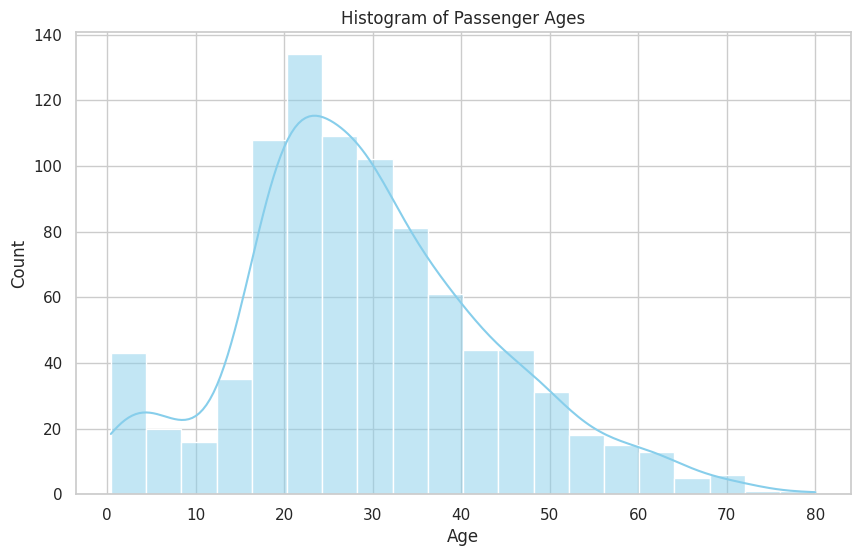

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
plt.title('Histogram of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [ ]:
# Bar Plot of Survived Rates by Class
plt.figure(figsize=(8, 5))
sns.barplot(x='PclassCategory', y='Survived', data=df, palette='pastel', errorbar=None)
plt.title('Survival Rates by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (Percentage)')
plt.show()

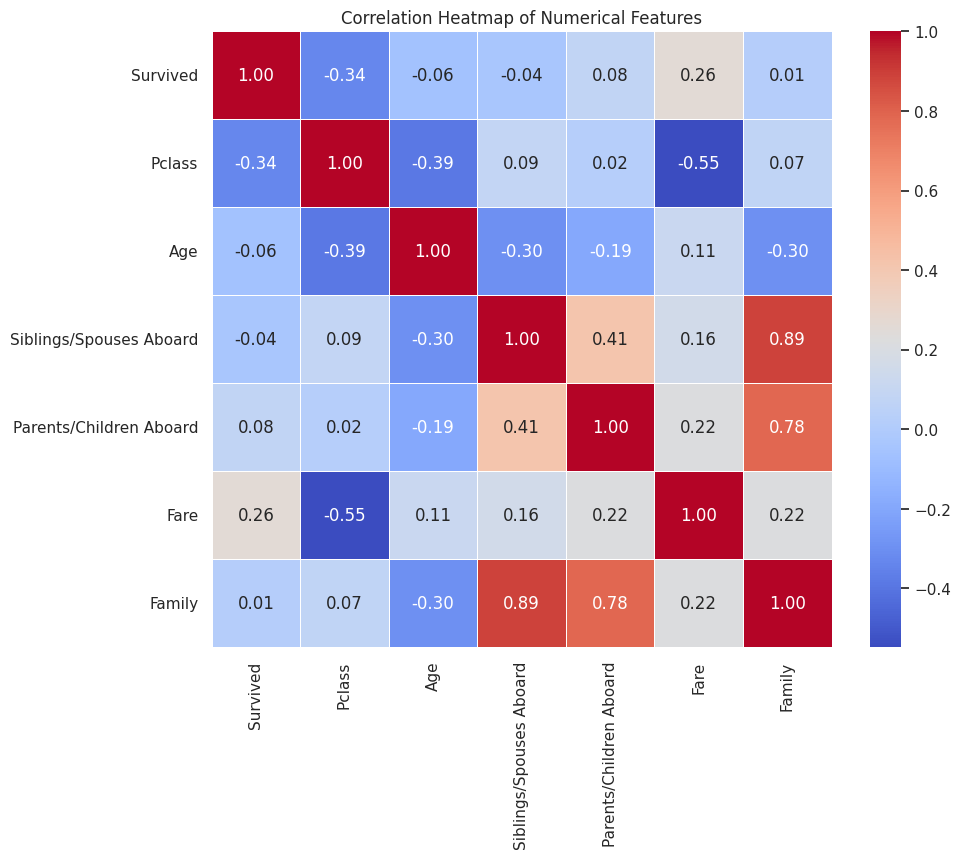

In [16]:
plt.figure(figsize=(10, 8))
# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=[np.number])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

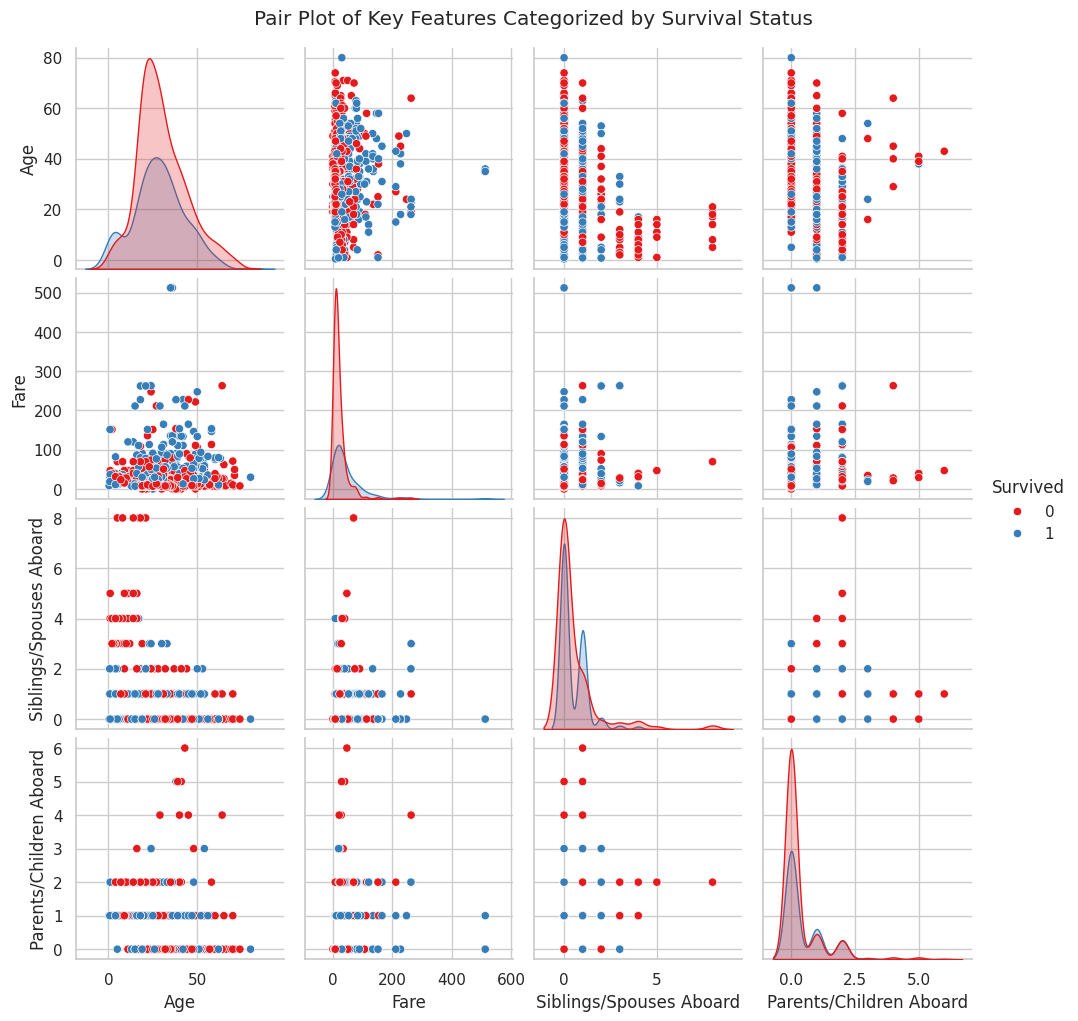

In [17]:
# Create a pair plot of 'Age', 'Fare', and family features, colored by 'Survived'
# Renaming the columns inside the plot execution temporarily for clean viewing
plot_df = df[['Age', 'Fare', 'Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Survived']].copy()

sns.pairplot(plot_df, hue='Survived', palette='Set1', diag_kind='kde')
plt.suptitle('Pair Plot of Key Features Categorized by Survival Status', y=1.02)
plt.show()

In [18]:
# Calculate and display survival rates by sex
survival_by_sex = df.groupby('Sex')['Survived'].mean()
print("Survival Rate by Sex:")
print(survival_by_sex)
print("-" * 30)

# Calculate and display survival rates by passenger class
survival_by_class = df.groupby('PclassCategory')['Survived'].mean()
print("Survival Rate by Class:")
print(survival_by_class)

Survival Rate by Sex:
Sex
female    0.742038
male      0.190227
Name: Survived, dtype: float64
------------------------------
Survival Rate by Class:
PclassCategory
1st Class    0.629630
2nd Class    0.472826
3rd Class    0.244353
Name: Survived, dtype: float64


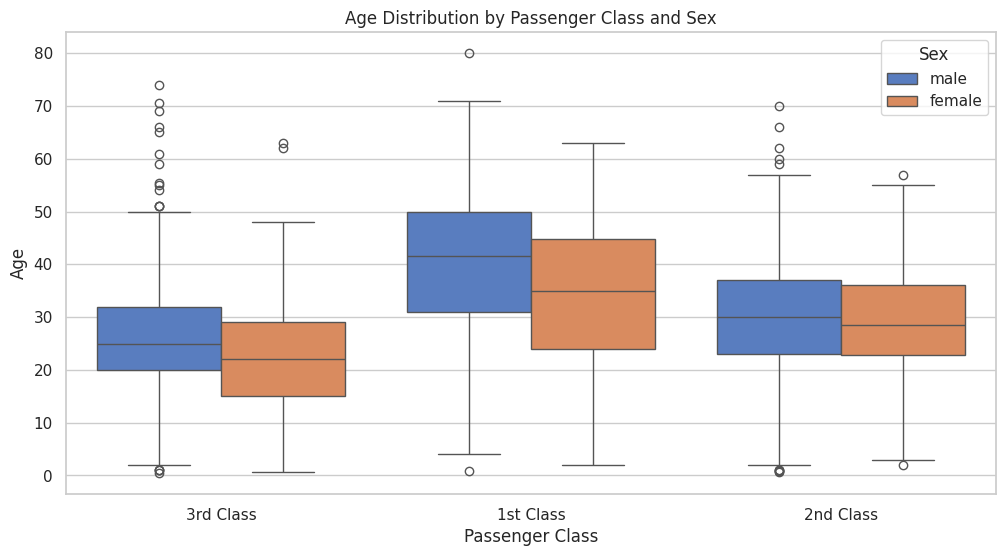

In [19]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='PclassCategory', y='Age', hue='Sex', data=df, palette='muted')
plt.title('Age Distribution by Passenger Class and Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Age')
plt.show()

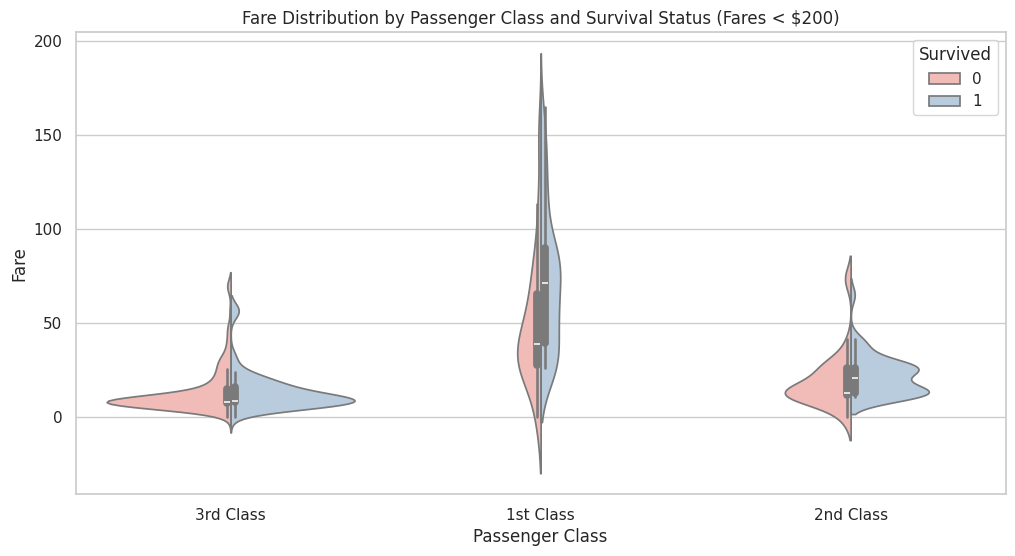

In [20]:
plt.figure(figsize=(12, 6))
# Filter out extreme outliers for Fare to make the violin plot readable
sns.violinplot(x='PclassCategory', y='Fare', hue='Survived', data=df[df['Fare'] < 200], split=True, palette='Pastel1')
plt.title('Fare Distribution by Passenger Class and Survival Status (Fares < $200)')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()

## Summary of Insights from Exploratory Data Analysis (EDA)

1. **The "Women and Children First" Protocol:** Females had a significantly higher survival rate than males. Sex is one of the strongest predictive features of survival in this dataset.
   
2. **Socioeconomic Status Impact:** Passengers in 1st Class (`1st Class`) had much higher survival rates compared to those in 3rd Class. The violin plots show that those who paid higher fares within their classes also had a better chance of survival.

3. **Age and Demographics:** The age distribution indicates a high number of young adults aboard (concentrated between 20 and 40 years old). 1st Class passengers skewed noticeably older than 3rd class passengers, as visualized in the box plots.

4. **Family Size Correlations:** The multi-index and pair plots hint that while traveling completely alone reduced survival chances, having an excessively large family size also correlates negatively with survival, likely due to the difficulty of coordinating evacuation.
